## Product Clustering

**Goal**
- Group reviews into 4–6 meta categories using embeddings.

In [4]:
!pip install sentence-transformers
import pandas as pd
from pathlib import Path

df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Prepare Text Data
- Using cleaned reviews as input for clustering.

In [5]:
#extract cleaned review text
texts = df["clean_review"].tolist()

#check number of reviews
len(texts)

83495

## Use Sample for Fast Experiment
- Starting with a smaller sample to test clustering quickly.

In [6]:
#use a sample first to avoid slow execution
sample_df = df.sample(n=1000, random_state=42).copy()

#extract sample texts
sample_texts = sample_df["clean_review"].tolist()

#check sample size
len(sample_texts)

1000

## Create Text Embeddings
- Converting reviews into numerical vectors using a pretrained sentence transformer.

In [7]:
from sentence_transformers import SentenceTransformer

#load embedding model (fast + good for clustering)
model = SentenceTransformer("all-MiniLM-L6-v2")

#create embeddings for sample reviews
embeddings = model.encode(sample_texts, show_progress_bar=True)

#check shape (rows = reviews, columns = vector size)
embeddings.shape

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)

## Apply KMeans Clustering
- Grouping reviews into 4–6 clusters.

In [8]:
from sklearn.cluster import KMeans

# define number of clusters (start with 5)
k = 5

# create and train KMeans
kmeans = KMeans(n_clusters=k, random_state=42)

# assign cluster to each review
sample_df["cluster"] = kmeans.fit_predict(embeddings)

# check results
sample_df[["clean_review", "cluster"]].head()

,clean_review,cluster
14296,super product and super price,4
22613,the paperwhite itself is a very nice design an...,0
32549,love this thing it s very useful and a lot of ...,2
23113,my daughter absolutely loves her new fire lots...,2
3272,as expected,4


## Inspect Cluster Sizes
- Checking how many reviews belong to each cluster.

In [9]:
# count reviews per cluster
sample_df["cluster"].value_counts().sort_index()

,count
cluster,
0,180
1,269
2,160
3,128
4,263


## Inspect Cluster Content
- Look at sample reviews from each cluster to understand what they represent.

In [10]:
#show 5 example reviews per cluster
for cluster_id in sorted(sample_df["cluster"].unique()):
    print(f"\n--- Cluster {cluster_id} ---\n")

    examples = sample_df[sample_df["cluster"] == cluster_id]["clean_review"].head(5)

    for review in examples:
        print("-", review[:150])  # print first 150 chars


--- Cluster 0 ---

- the paperwhite itself is a very nice design and the size makes it portable and easy to hold the fact that you will be purchasing books from amazon mak
- upgraded from the original kindle not sure why we waited so long
- we bought this to use instead of an ipad for reading books it s a great buy no glare from sunlight or lightbulbs and super light and easy to carry aro
- perfect size for travel holds a lot of books easy to download to
- i know many people who have a kindle it frees up using the cell phone memory so i bought this one for the amount of storage it has as well as the cost

--- Cluster 1 ---

- i love this tablet and so do my children i have been wanting to get one for a couple years but never had any wifi to use it with all the features and 
- works good quality for videos aren t that great but it s good for surfacing the web games books ect
- good inexpensive tablet for my daughter i picked up on black friday for 50 bucks she loves it
- without a doub

## Assign Meaningful Names to Clusters
- Based on the example reviews, giving each cluster a human-readable category name.

In [11]:
#assign names manually based on what you observed
cluster_names = {
    0: "Batteries / Power",
    1: "Electronics / Devices",
    2: "Accessories",
    3: "Home / Everyday Products",
    4: "Other"
}

#map cluster ids to names
sample_df["cluster_name"] = sample_df["cluster"].map(cluster_names)

#check result
sample_df[["clean_review", "cluster", "cluster_name"]].head()

,clean_review,cluster,cluster_name
14296,super product and super price,4,Other
22613,the paperwhite itself is a very nice design an...,0,Batteries / Power
32549,love this thing it s very useful and a lot of ...,2,Accessories
23113,my daughter absolutely loves her new fire lots...,2,Accessories
3272,as expected,4,Other


## Save Clustered Sample
- Store clustering results for later use (e.g. summarization).

In [14]:
from pathlib import Path

# create outputs folder inside Colab
output_path = Path("/content/outputs/clustered_sample.csv")
output_path.parent.mkdir(exist_ok=True)

# save clustered data
sample_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/outputs/clustered_sample.csv


## Top Words per Cluster
Visualizing the most important words in each cluster.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

#create TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)

#fit on sample texts
X_tfidf = vectorizer.fit_transform(sample_df["clean_review"])

#get feature names (words)
terms = vectorizer.get_feature_names_out()

#for each cluster → show top words
for cluster_id in sorted(sample_df["cluster"].unique()):
    print(f"\n--- Cluster {cluster_id} ---")

    cluster_indices = (sample_df["cluster"] == cluster_id).values
    cluster_tfidf = X_tfidf[cluster_indices]

    #average TF-IDF score per word
    mean_tfidf = cluster_tfidf.mean(axis=0).A1

    #get top 10 words
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_words = [terms[i] for i in top_indices]

    print("Top words:", ", ".join(top_words))


--- Cluster 0 ---
Top words: kindle, books, read, reading, love, easy, great, use, reader, good

--- Cluster 1 ---
Top words: tablet, great, kids, apps, price, good, use, amazon, bought, love

--- Cluster 2 ---
Top words: bought, loves, love, use, kids, gift, easy, great, old, fun

--- Cluster 3 ---
Top words: echo, alexa, music, amazon, love, use, weather, great, speaker, things

--- Cluster 4 ---
Top words: batteries, great, price, good, product, just, work, works, value, easy


## Word Cloud per Cluster
- Visual representation of most frequent words in each cluster.

In [18]:
!pip install wordcloud

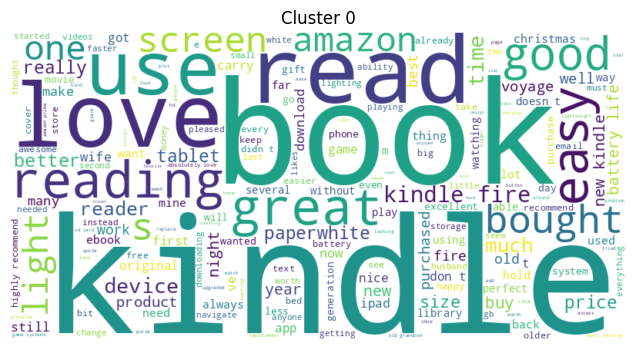

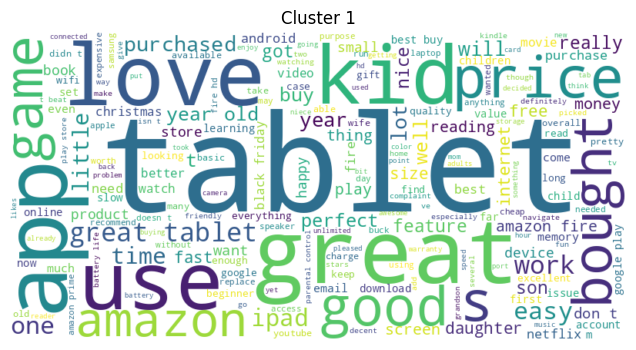

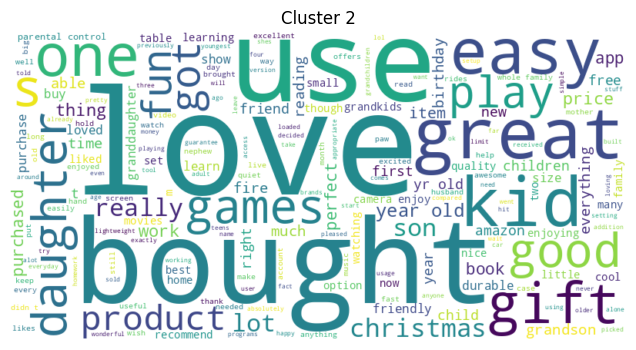

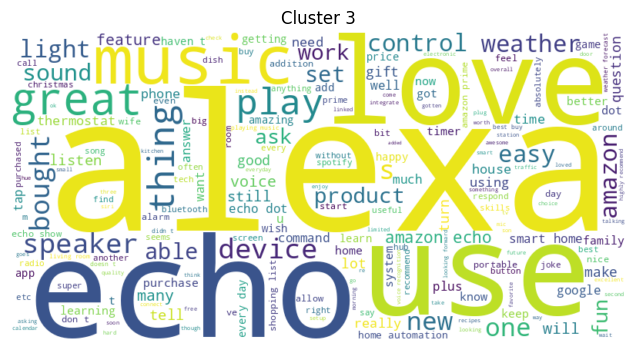

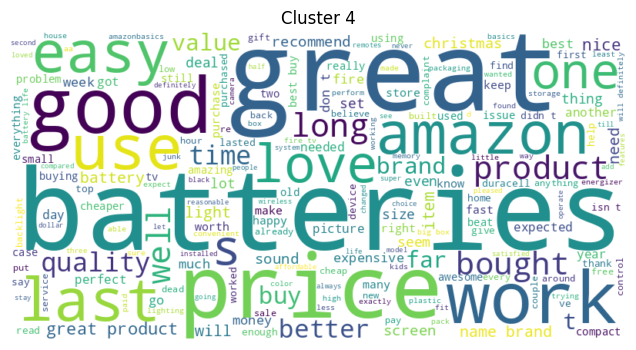

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# generate word cloud per cluster
for cluster_id in sorted(sample_df["cluster"].unique()):
    text = " ".join(sample_df[sample_df["cluster"] == cluster_id]["clean_review"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(8,4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Cluster {cluster_id}")
    plt.axis("off")
    plt.show()


## Clustering Evaluation
- Evaluating cluster quality using Silhouette Score.

In [20]:
from sklearn.metrics import silhouette_score

# calculate silhouette score
score = silhouette_score(embeddings, sample_df["cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.071638696


## Clustering Insights

- Silhouette score is relatively low (~0.07), indicating weak cluster separation
- This is expected for text data, where reviews often share similar vocabulary
- Despite the low score, clusters show meaningful themes when inspecting top words
- Therefore, qualitative evaluation (top words, examples) is more informative than quantitative metrics alone